1. File Path and Year Setup

This section defines the file path where the property assessment data files are stored and specifies the years we want to process (2021-2024). An empty list is initialized to store processed data for each year, and a dictionary is created to keep track of HEAT_SYSTEM distribution counts for each year.

In [10]:
import pandas as pd
import os
import re
from collections import Counter

In [11]:
# Define the file path and years to process
file_path = r'C:\Users\sul19\Desktop\701 Project\Property Assessment Datasets'
years = range(2021, 2025)  # Only years from 2021 to 2024
output_data = []

In [12]:
# Dictionary to store HEAT_SYSTEM counts per year
heat_system_counts_by_year = {year: {"C - Common": 0, "I - Indiv. Cntrl": 0, "N - None": 0, "Y - Self Contained": 0} for year in years}

2. Data Processing Loop for Each Year

For each specified year, this loop loads the corresponding Excel file, cleans up the ZIP_CODE column, and processes the owner occupancy, heating system, and bedroom data. The OWN_OCC column is converted to numeric values (1 for owner-occupied, 0 for not). The most common HEAT_SYSTEM is computed by ZIP code while ignoring blanks, and the average number of bedrooms (BED_RMS) is calculated, ignoring blanks but retaining rows with missing values.

3. Calculating HEAT_SYSTEM Mode Ignoring Blanks

The mode_ignore_blanks function calculates the most common HEAT_SYSTEM value within each ZIP code while ignoring blank values. The mode for each ZIP code is calculated using this function, and the results are merged back into the main data grouped by ZIP codes.

4. Adding Year and Storing Data

After calculating owner occupancy, heating system mode, and average number of bedrooms, the YEAR column is added to identify the data year. The data for each year is appended to the list output_data, which will later be combined into a single DataFrame.

5. Updating Annual HEAT_SYSTEM Counts

For each year, we calculate the total counts of each HEAT_SYSTEM type, which will later be used to generate pie charts visualizing the heating system distribution by year.

In [16]:
# Loop through each year, process the files, and calculate the mode HEAT_SYSTEM for each ZIP_CODE, ignoring blanks
for year in years:
    file_name = f'Property Assessment {year} V1.xlsx'
    file = os.path.join(file_path, file_name)
    df = pd.read_excel(file)
    
    # Clean up ZIP_CODE column by removing any trailing underscores or ".0"
    df['ZIP_CODE'] = df['ZIP_CODE'].astype(str).apply(lambda x: re.sub(r'(_|\.0)$', '', x)).str.zfill(5)
    
    # Calculate owner occupancy based on all rows
    df['OWN_OCC'] = df['OWN_OCC'].map({'Y': 1, 'N': 0})
    zip_group = df.groupby('ZIP_CODE').agg({
        'OWN_OCC': lambda x: 'Owner-occupied' if x.mean() >= 0.5 else 'Not owner-occupied',
        # **NEW CODE START**: Calculate average BED_RMS, ignoring blanks
        'BED_RMS': lambda x: x.dropna().mean()
        # **NEW CODE END**
    }).reset_index()

    # Calculate mode for HEAT_SYSTEM by ignoring blanks
    def mode_ignore_blanks(series):
        # Filter out blank values
        non_blank_series = series.dropna().replace("", pd.NA).dropna()
        if not non_blank_series.empty:
            return Counter(non_blank_series).most_common(1)[0][0]
        return None  # Return None if no non-blank values are present

    # Apply the mode_ignore_blanks function for each ZIP_CODE
    heat_mode = df.groupby('ZIP_CODE')['HEAT_SYSTEM'].apply(mode_ignore_blanks).reset_index()
    heat_mode.columns = ['ZIP_CODE', 'HEAT_SYSTEM']

    # Merge HEAT_SYSTEM mode with the main ZIP group
    zip_group = zip_group.merge(heat_mode, on='ZIP_CODE', how='left')

    # Add the YEAR column to the aggregated data
    zip_group['YEAR'] = year
    
    # Append the processed data to output_data list
    output_data.append(zip_group)
    
    # Update HEAT_SYSTEM counts for each year
    year_counts = df['HEAT_SYSTEM'].value_counts()
    for heat_type, count in year_counts.items():
        if heat_type in heat_system_counts_by_year[year]:  # Check if heat_type is a known type
            heat_system_counts_by_year[year][heat_type] += count
        else:
            # Handle any unexpected heat types by adding them to the dictionary with the current count
            heat_system_counts_by_year[year][heat_type] = count

6. Combining Processed Data for All Years

Once all years are processed, we concatenate the yearly data stored in output_data into a single DataFrame and save it as a new Excel file for future reference.

In [17]:
# Combine all years' data into a single DataFrame
final_df = pd.concat(output_data, ignore_index=True)

# Save the final DataFrame to a new Excel file
output_file = os.path.join(file_path, 'Property_Assessment_OWNOCC_HEATSYS_Mode_2021_2024_Final2.xlsx')
final_df.to_excel(output_file, index=False)

print(f"File saved successfully at {output_file}")


File saved successfully at C:\Users\sul19\Desktop\701 Project\Property Assessment Datasets\Property_Assessment_OWNOCC_HEATSYS_Mode_2021_2024_Final2.xlsx


7. Heatmap of Owner Occupancy by ZIP Code and Year

This section loads the saved Excel file and prepares a heatmap to visualize owner-occupancy trends across ZIP codes and years. OWN_OCC is converted to numeric values (1 for owner-occupied, 0 for not), and a pivot table is created to structure the data for heatmap visualization.

8. Heatmap of Average Bedrooms by ZIP Code and Year

New Code Added: To visualize the trend of average bedrooms per ZIP code over the years, we prepare a pivot table similar to the owner-occupancy heatmap but using BED_RMS data, and create a heatmap.

9. Pie Charts for HEAT_SYSTEM Distribution by Year

Finally, we generate pie charts to visualize the distribution of HEAT_SYSTEM types for each year using the heat_system_counts_by_year dictionary created earlier. The pie charts help illustrate heating system usage changes over time.

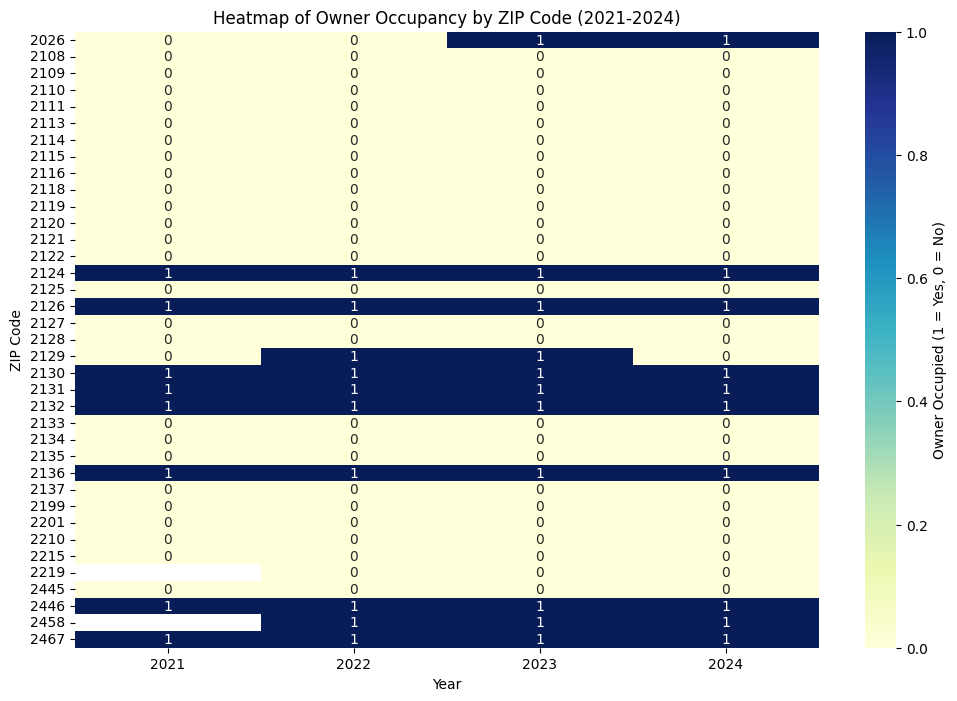

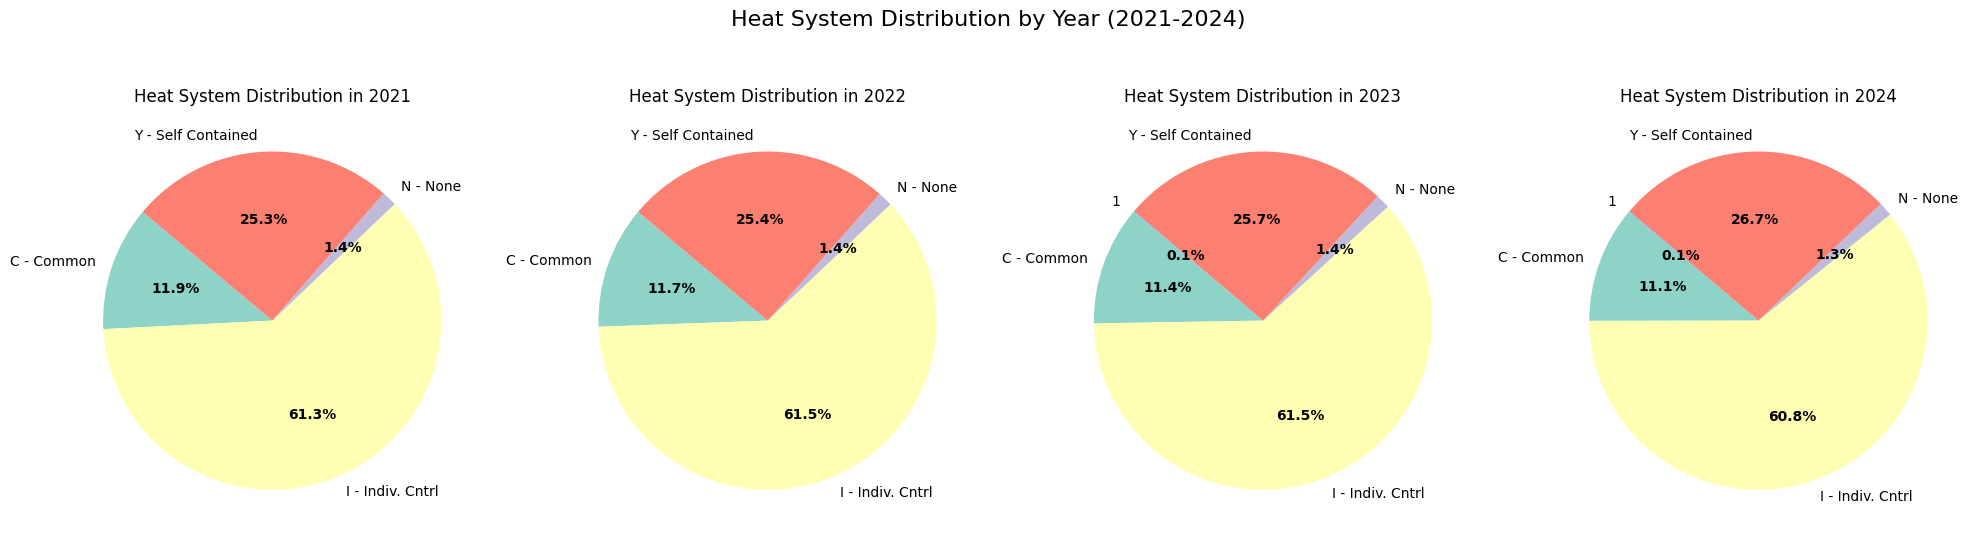

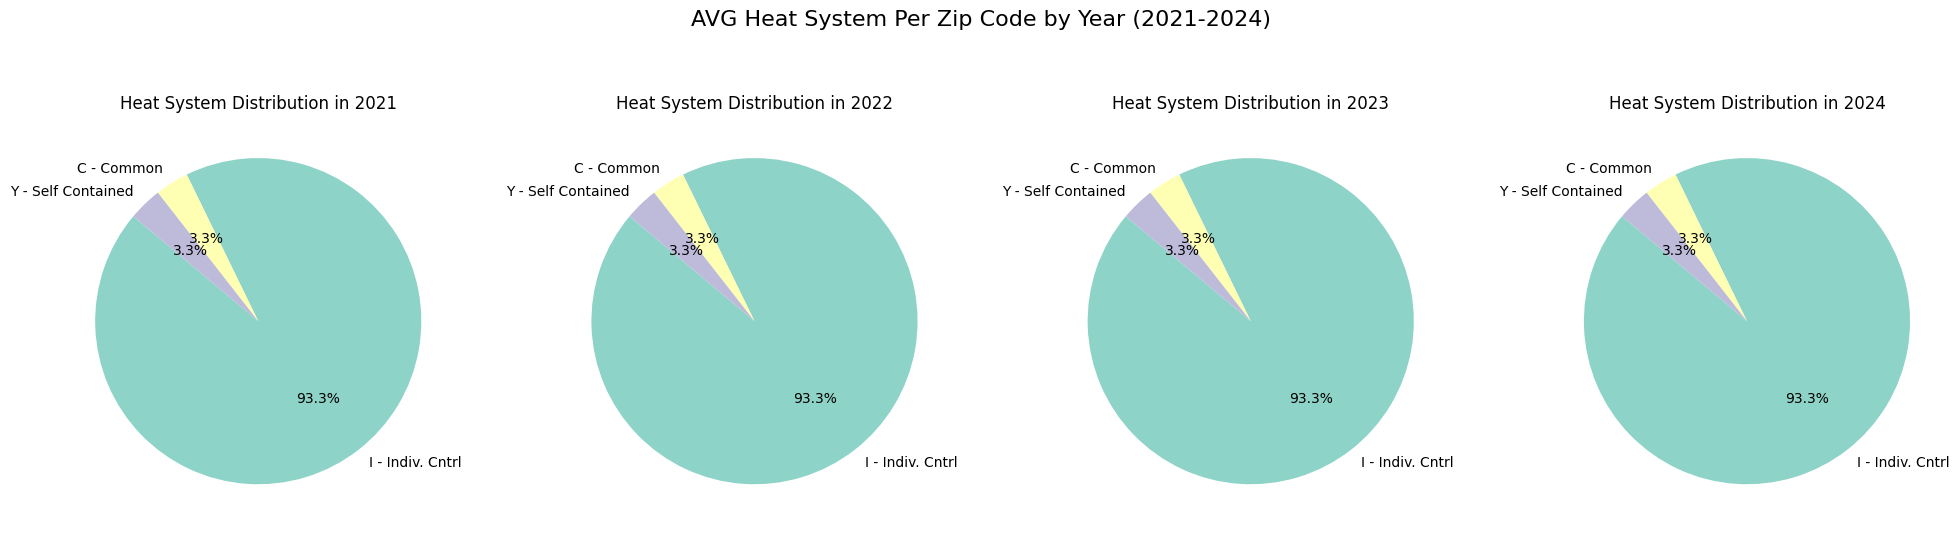

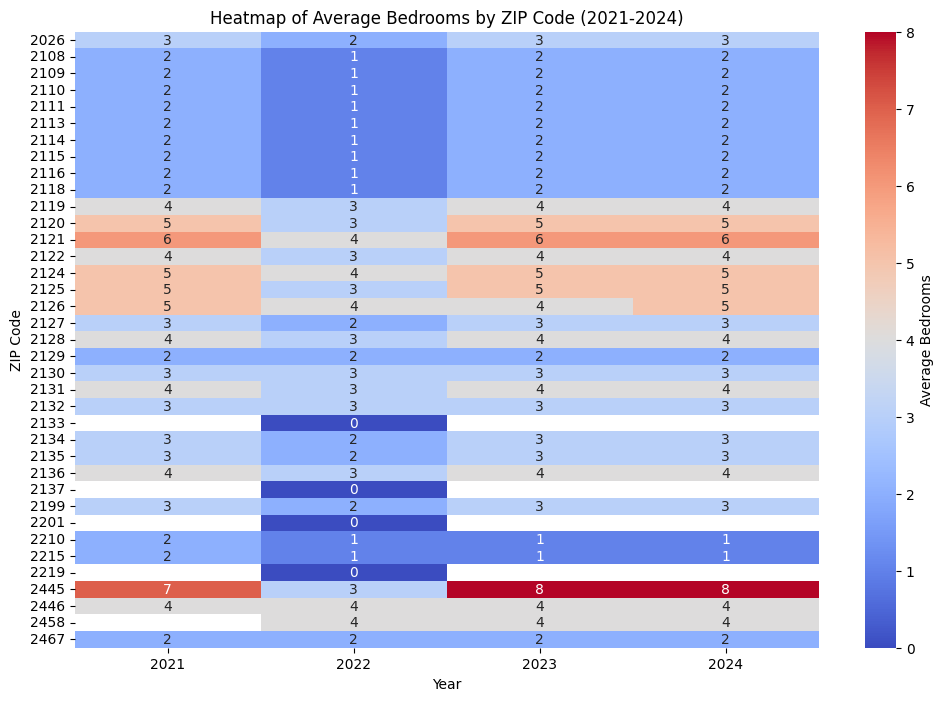

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data file
file_path_output = r'C:\Users\sul19\Desktop\701 Project\Property Assessment Datasets\Property_Assessment_OWNOCC_HEATSYS_Mode_2021_2024_Final2.xlsx'
df = pd.read_excel(file_path_output)

# Convert OWN_OCC to numeric values for the heatmap
# Owner-occupied = 1, Not owner-occupied = 0
# Ensure each ZIP_CODE-YEAR combination is unique by averaging OWN_OCC_NUMERIC for duplicates
df['OWN_OCC_NUMERIC'] = df['OWN_OCC'].map({'Owner-occupied': 1, 'Not owner-occupied': 0})
df_unique = df.groupby(['ZIP_CODE', 'YEAR'], as_index=False)['OWN_OCC_NUMERIC'].mean()

# Pivot data for heatmap: rows = ZIP_CODE, columns = YEAR, values = averaged OWN_OCC_NUMERIC
heatmap_data = df_unique.pivot(index="ZIP_CODE", columns="YEAR", values="OWN_OCC_NUMERIC")

# Create heatmap for OWN_OCC changes over years
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, cbar_kws={'label': 'Owner Occupied (1 = Yes, 0 = No)'})
plt.title('Heatmap of Owner Occupancy by ZIP Code (2021-2024)')
plt.xlabel('Year')
plt.ylabel('ZIP Code')
plt.show()

# Generate pie charts for HEAT_SYSTEM distribution for each year - **NEW CODE START**
fig, axes = plt.subplots(1, len(years), figsize=(20, 6))  # One row for pie charts for each year

for i, year in enumerate(years):
    heat_counts = heat_system_counts_by_year[year]
    
    # Plot pie chart on the respective axis for each year
    wedges, texts, autotexts = axes[i].pie(
        heat_counts.values(), labels=heat_counts.keys(), autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors
    )
    axes[i].set_title(f'Heat System Distribution in {year}')
    plt.setp(autotexts, size=10, weight="bold")  # Make autopct text more readable

plt.suptitle('Heat System Distribution by Year (2021-2024)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
plt.show()
# **NEW CODE END**

# Generate pie charts for HEAT_SYSTEM distribution for each year
years = df['YEAR'].unique()
fig, axes = plt.subplots(1, len(years), figsize=(20, 6))

for i, year in enumerate(years):
    year_data = df[df['YEAR'] == year]
    heat_counts = year_data['HEAT_SYSTEM'].value_counts()
    
    # Plot pie chart on the respective axis
    axes[i].pie(heat_counts, labels=heat_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)
    axes[i].set_title(f'Heat System Distribution in {year}')

plt.suptitle('AVG Heat System Per Zip Code by Year (2021-2024)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
plt.show()

# **NEW CODE START**: Heatmap for Average Bedrooms (BED_RMS) by ZIP Code and Year
df_bedrooms = df.groupby(['ZIP_CODE', 'YEAR'], as_index=False)['BED_RMS'].mean().round()
bedroom_heatmap_data = df_bedrooms.pivot(index="ZIP_CODE", columns="YEAR", values="BED_RMS")

plt.figure(figsize=(12, 8))
sns.heatmap(bedroom_heatmap_data, cmap="coolwarm", annot=True, cbar_kws={'label': 'Average Bedrooms'})
plt.title('Heatmap of Average Bedrooms by ZIP Code (2021-2024)')
plt.xlabel('Year')
plt.ylabel('ZIP Code')
plt.show()
# **NEW CODE END**

Owner-Occupancy
"Y" indicates the property is owner-occupied. The owner receives a residential exemption, which typically provides a tax benefit for primary residences where the owner lives on the property.
"N" indicates that the property is not owner-occupied. The owner doesn't receive the resedential exemption, suggesting the property is likely used as a rental or investrment property rather than as the owner's primary residence. Useful for students seeking housing options in areas with higher rental availability. 